## Dataset Overview

In [1]:
pip install nibabel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Imports and Dataset Paths

In [2]:
import os
import glob
import re
import warnings

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Project directory
PROJECT_DIR = os.getcwd()

# Dataset directory
DATASET_DIR = os.path.join(PROJECT_DIR, "Dataset")

AD_MRI_DIR = os.path.join(DATASET_DIR, "AD", "MR")
HC_MRI_DIR = os.path.join(DATASET_DIR, "HC", "MR_out")
HC_PET_DIR = os.path.join(DATASET_DIR, "HC", "PET")
MASK_ICV_PATH = os.path.join(DATASET_DIR, "mask_ICV.nii")
RMASK_ICV_PATH = os.path.join(DATASET_DIR, "rmask_ICV.nii")
AAL_ATLAS_PATH = os.path.join(DATASET_DIR, "aal.nii")
SEX_LIST_PATH = os.path.join(DATASET_DIR, "sex_list.csv")

# AD & HC image files
ad_mri_files = sorted(glob.glob(os.path.join(AD_MRI_DIR, "*.nii.gz")))
hc_mri_files = sorted(glob.glob(os.path.join(HC_MRI_DIR, "*.nii.gz")))
hc_pet_files = sorted(glob.glob(os.path.join(HC_PET_DIR, "*.nii.gz")))


### 2. Subject and Modality Overview

In [3]:
# Count AD and HC MRI and HC PET files
print("AD MRI files:", len(ad_mri_files))
print("HC MRI files:", len(hc_mri_files))
print("HC PET files:", len(hc_pet_files))

# Extract subject IDs from filenames
def extract_subject_id(filename):
    match = re.search(r'(\d{3}_S_\d{4})', os.path.basename(filename))
    return match.group(1) if match else None

# Extract subject IDs for AD MRI, HC MRI and HC PET
ad_mri_subject_ids = [extract_subject_id(f) for f in ad_mri_files]
hc_mri_subject_ids = [extract_subject_id(f) for f in hc_mri_files]
hc_pet_subject_ids = [extract_subject_id(f) for f in hc_pet_files]

print("Unique AD MRI subjects:", len(set(ad_mri_subject_ids)))
print("Unique HC MRI subjects:", len(set(hc_mri_subject_ids)))
print("Unique HC PET subjects:", len(set(hc_pet_subject_ids)))

# Compare MRI and PET subject availability in HC
hc_mri_subject_set = set(hc_mri_subject_ids)
hc_pet_subject_set = set(hc_pet_subject_ids)

pet_with_mri = hc_pet_subject_set.intersection(hc_mri_subject_set)

print("HC subjects with both MRI and PET:", len(pet_with_mri))
print("HC subjects with MRI only:", len(hc_mri_subject_set - hc_pet_subject_set))
print("HC subjects with PET only:", len(hc_pet_subject_set - hc_mri_subject_set))

AD MRI files: 106
HC MRI files: 346
HC PET files: 139
Unique AD MRI subjects: 106
Unique HC MRI subjects: 346
Unique HC PET subjects: 139
HC subjects with both MRI and PET: 139
HC subjects with MRI only: 207
HC subjects with PET only: 0


### 3. Image Properties and Consistency

In [4]:
# Load representative AD MRI, HC MRI and HC PET images
ad_mri_img = nib.load(ad_mri_files[0])
mri_img = nib.load(hc_mri_files[0])
pet_img = nib.load(hc_pet_files[0])

# Representative image properties
image_properties = pd.DataFrame([
    {"Modality": "AD MRI", "Shape": ad_mri_img.shape, "Voxel size": ad_mri_img.header.get_zooms()[:3], "Data type": ad_mri_img.get_data_dtype()},
    {"Modality": "HC MRI", "Shape": mri_img.shape, "Voxel size": mri_img.header.get_zooms()[:3], "Data type": mri_img.get_data_dtype()},
    {"Modality": "HC PET", "Shape": pet_img.shape, "Voxel size": pet_img.header.get_zooms()[:3], "Data type": pet_img.get_data_dtype()}])

display(image_properties)

# Check image consistency across all subjects
metadata = []
for modality, files in [("AD MRI", ad_mri_files), ("HC MRI", hc_mri_files), ("HC PET", hc_pet_files)]:
    for file in files:
        img = nib.load(file)
        metadata.append({
            "Modality": modality,
            "Subject ID": extract_subject_id(file),
            "Shape": img.shape,
            "Voxel size": img.header.get_zooms()[:3],
            "Data type": img.get_data_dtype()
        })

metadata_df = pd.DataFrame(metadata)

# Unique shape, voxel-size and data-type summary
consistency_summary = (
    metadata_df.groupby(["Modality", "Shape", "Voxel size", "Data type"]).size()
    .reset_index(name="Number of Images"))

display(consistency_summary)

,Modality,Shape,Voxel size,Data type
0,AD MRI,"(105, 127, 105)","(1.5, 1.5, 1.5)",>u2
1,HC MRI,"(105, 127, 105)","(1.5, 1.5, 1.5)",float32
2,HC PET,"(105, 127, 105)","(1.5, 1.5, 1.5)",int16


,Modality,Shape,Voxel size,Data type,Number of Images
0,AD MRI,"(105, 127, 105)","(1.5, 1.5, 1.5)",>u2,76
1,AD MRI,"(105, 127, 105)","(1.5, 1.5, 1.5)",>i2,30
2,HC MRI,"(105, 127, 105)","(1.5, 1.5, 1.5)",float32,346
3,HC PET,"(105, 127, 105)","(1.5, 1.5, 1.5)",int16,139


### 4. Mask and Atlas Properties

In [5]:
# Load mask and AAL atlas
mask_icv_img = nib.load(MASK_ICV_PATH)
rmask_icv_img = nib.load(RMASK_ICV_PATH)
aal_img = nib.load(AAL_ATLAS_PATH)

# Mask and atlas properties
mask_atlas_properties = pd.DataFrame([
    {"Image": "mask_ICV.nii",
        "Shape": mask_icv_img.shape, "Voxel size": mask_icv_img.header.get_zooms()[:3],
        "Data type": mask_icv_img.get_data_dtype()},
    
    {"Image": "rmask_ICV.nii", "Shape": rmask_icv_img.shape,
        "Voxel size": rmask_icv_img.header.get_zooms()[:3], "Data type": rmask_icv_img.get_data_dtype()},
    
    {"Image": "AAL Atlas", "Shape": aal_img.shape,
        "Voxel size": aal_img.header.get_zooms()[:3], "Data type": aal_img.get_data_dtype()}])

display(mask_atlas_properties)

# Check spatial alignment between AD/HC MRI and rmask_ICV
ad_affine_difference = np.max(np.abs(ad_mri_img.affine - rmask_icv_img.affine))
hc_affine_difference = np.max(np.abs(mri_img.affine - rmask_icv_img.affine))

print("Maximum affine difference between AD MRI and rmask_ICV:", ad_affine_difference)
print("Maximum affine difference between HC MRI and rmask_ICV:", hc_affine_difference)

,Image,Shape,Voxel size,Data type
0,mask_ICV.nii,"(121, 145, 121)","(1.5, 1.5, 1.5)",uint8
1,rmask_ICV.nii,"(105, 127, 105)","(1.5, 1.5, 1.5)",uint8
2,AAL Atlas,"(181, 217, 181)","(1.0, 1.0, 1.0)",uint8


Maximum affine difference between AD MRI and rmask_ICV: 0.0
Maximum affine difference between HC MRI and rmask_ICV: 0.0


###  5. Atlas Labels and Mask Coverage

In [6]:
# Extract unique labels from the AAL atlas
aal_data = aal_img.get_fdata()
aal_labels = np.unique(aal_data)
aal_labels = aal_labels[aal_labels != 0]

# Calculate non-zero voxel statistics
mask_icv_data = mask_icv_img.get_fdata()
rmask_icv_data = rmask_icv_img.get_fdata()

mask_icv_nonzero = np.count_nonzero(mask_icv_data)
rmask_icv_nonzero = np.count_nonzero(rmask_icv_data)

# Atlas label summary
atlas_summary = pd.DataFrame([{
    "Atlas": "AAL",
    "Non-background labels": len(aal_labels),
    "Minimum label": int(aal_labels.min()),
    "Maximum label": int(aal_labels.max())}])

display(atlas_summary)

# Mask coverage summary
mask_coverage = pd.DataFrame([
    {
        "Image": "mask_ICV.nii",
        "Total voxels": mask_icv_data.size,
        "Non-zero voxels": mask_icv_nonzero,
        "Non-zero percentage": (mask_icv_nonzero / mask_icv_data.size) * 100
    },
    {
        "Image": "rmask_ICV.nii",
        "Total voxels": rmask_icv_data.size,
        "Non-zero voxels": rmask_icv_nonzero,
        "Non-zero percentage": (rmask_icv_nonzero / rmask_icv_data.size) * 100
    }
])

display(mask_coverage)

,Atlas,Non-background labels,Minimum label,Maximum label
0,AAL,116,1,116


,Image,Total voxels,Non-zero voxels,Non-zero percentage
0,mask_ICV.nii,2122945,558718,26.318063
1,rmask_ICV.nii,1400175,558043,39.855232


### 6. AD and HC MRI and PET Visualization

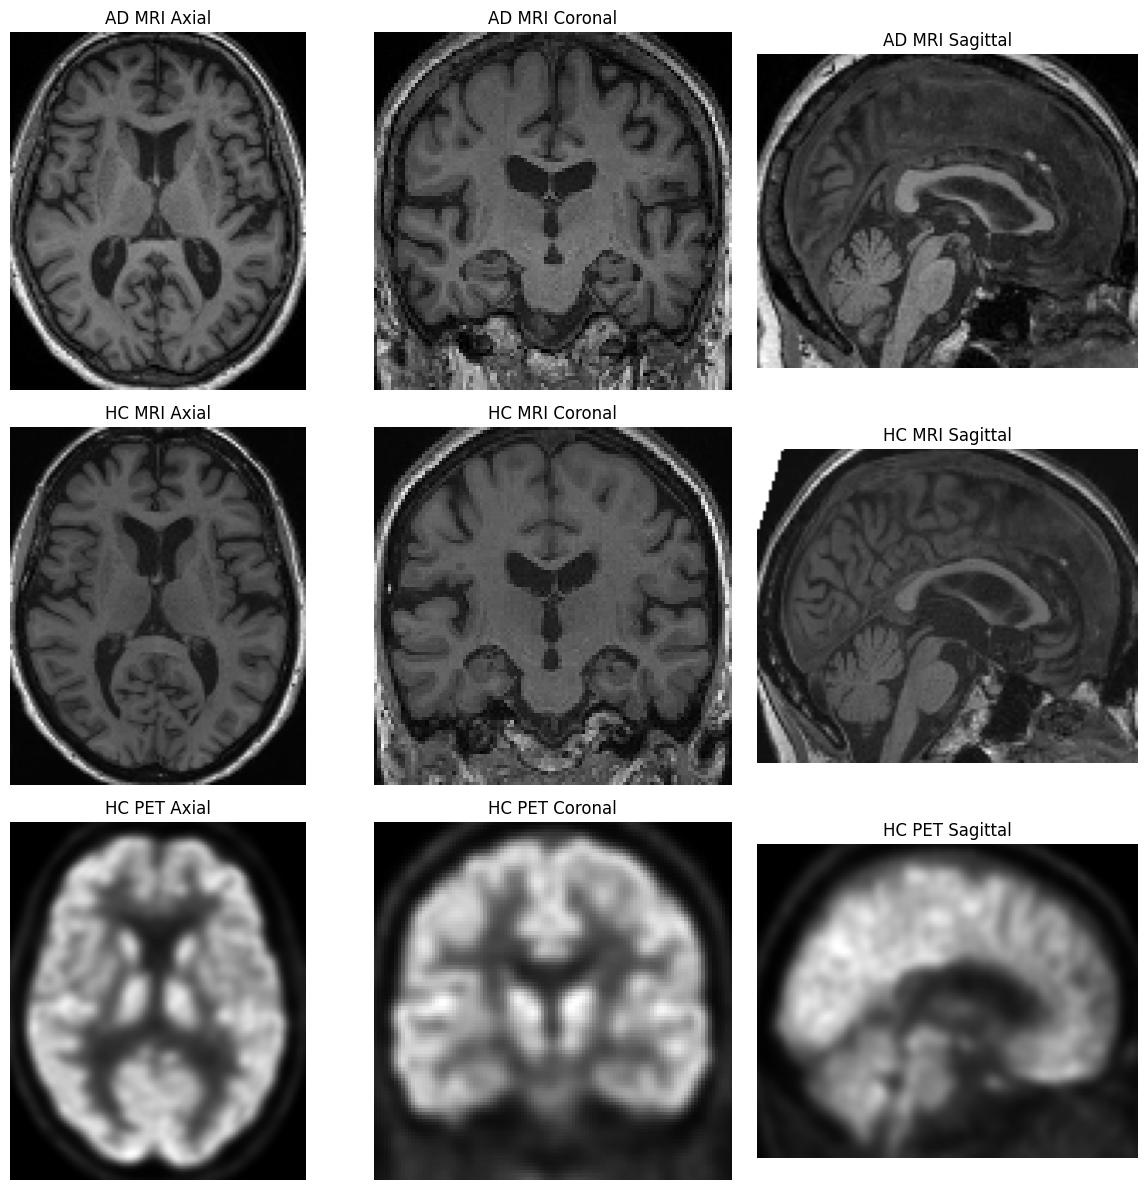

In [7]:
# Load representative AD MRI, HC MRI and HC PET
ad_mri_data = ad_mri_img.get_fdata()
mri_data = mri_img.get_fdata()
pet_data = pet_img.get_fdata()

# Select middle slices from three anatomical planes
ad_axial = ad_mri_data[:, :, ad_mri_data.shape[2] // 2]
ad_coronal = ad_mri_data[:, ad_mri_data.shape[1] // 2, :]
ad_sagittal = ad_mri_data[ad_mri_data.shape[0] // 2, :, :]

mri_axial = mri_data[:, :, mri_data.shape[2] // 2]
mri_coronal = mri_data[:, mri_data.shape[1] // 2, :]
mri_sagittal = mri_data[mri_data.shape[0] // 2, :, :]

pet_axial = pet_data[:, :, pet_data.shape[2] // 2]
pet_coronal = pet_data[:, pet_data.shape[1] // 2, :]
pet_sagittal = pet_data[pet_data.shape[0] // 2, :, :]

# Display AD MRI, HC MRI and HC PET in three anatomical planes
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

images = [
    (ad_axial, "AD MRI Axial"), (ad_coronal, "AD MRI Coronal"), (ad_sagittal, "AD MRI Sagittal"),
    (mri_axial, "HC MRI Axial"), (mri_coronal, "HC MRI Coronal"), (mri_sagittal, "HC MRI Sagittal"),
    (pet_axial, "HC PET Axial"), (pet_coronal, "HC PET Coronal"), (pet_sagittal, "HC PET Sagittal")
]

for ax, (image, title) in zip(axes.flat, images):
    ax.imshow(image.T, cmap="gray", origin="lower")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

### 7. AD and HC MRI with Mask Visualization

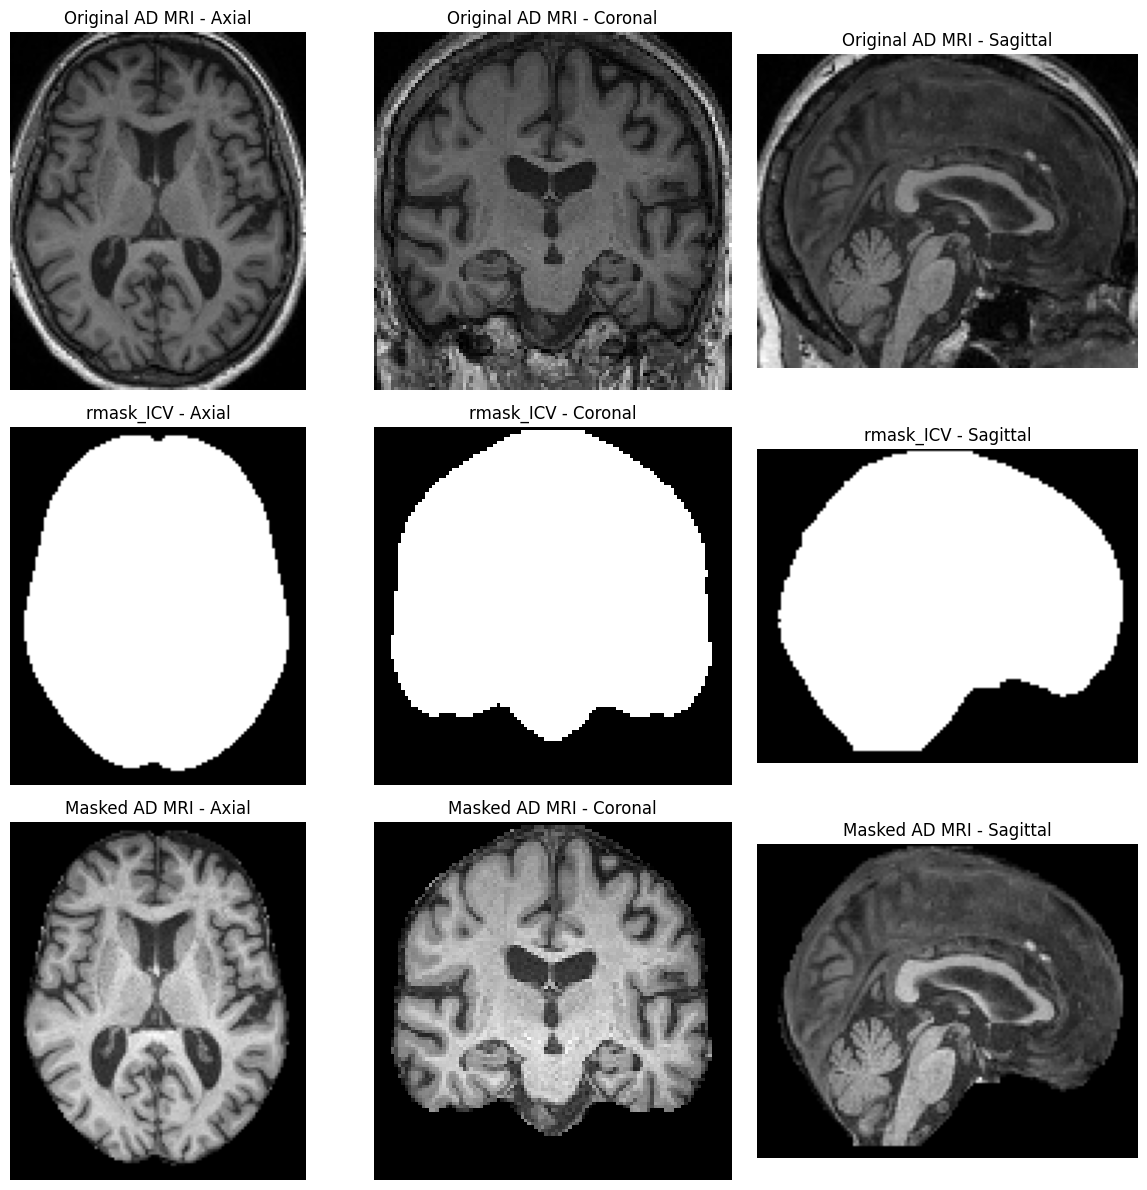

In [8]:
# Apply the MRI-compatible rmask_ICV mask to AD MRI
ad_mri_data = ad_mri_img.get_fdata()
rmask_data = rmask_icv_img.get_fdata()
masked_ad_mri = ad_mri_data * rmask_data

# Select middle slices from three anatomical planes
original_slices = [
    ad_mri_data[:, :, ad_mri_data.shape[2] // 2],
    ad_mri_data[:, ad_mri_data.shape[1] // 2, :],
    ad_mri_data[ad_mri_data.shape[0] // 2, :, :]]

mask_slices = [
    rmask_data[:, :, rmask_data.shape[2] // 2],
    rmask_data[:, rmask_data.shape[1] // 2, :],
    rmask_data[rmask_data.shape[0] // 2, :, :]]

masked_slices = [
    masked_ad_mri[:, :, masked_ad_mri.shape[2] // 2],
    masked_ad_mri[:, masked_ad_mri.shape[1] // 2, :],
    masked_ad_mri[masked_ad_mri.shape[0] // 2, :, :]]

# Display AD MRI, mask and masked AD MRI
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
plane_names = ["Axial", "Coronal", "Sagittal"]

for i in range(3):
    axes[0, i].imshow(original_slices[i].T, cmap="gray", origin="lower")
    axes[0, i].set_title(f"Original AD MRI - {plane_names[i]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(mask_slices[i].T, cmap="gray", origin="lower")
    axes[1, i].set_title(f"rmask_ICV - {plane_names[i]}")
    axes[1, i].axis("off")

    axes[2, i].imshow(masked_slices[i].T, cmap="gray", origin="lower")
    axes[2, i].set_title(f"Masked AD MRI - {plane_names[i]}")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

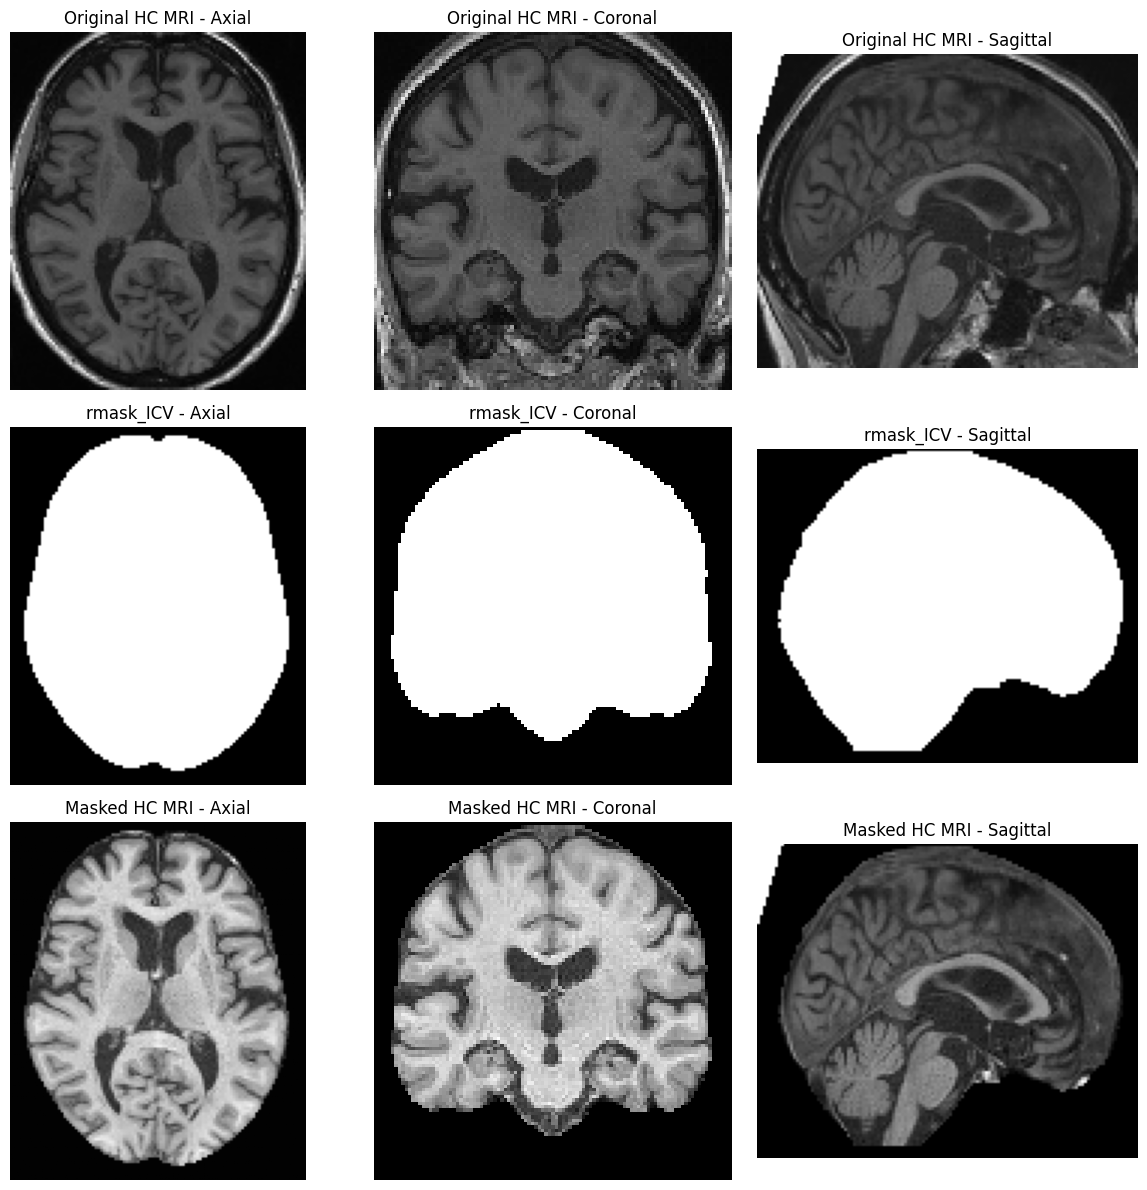

In [9]:
# Apply the MRI-compatible rmask_ICV mask to HC MRI
rmask_data = rmask_icv_img.get_fdata()
masked_mri = mri_data * rmask_data

# Select middle slices from three anatomical planes
original_slices = [
    mri_data[:, :, mri_data.shape[2] // 2],
    mri_data[:, mri_data.shape[1] // 2, :],
    mri_data[mri_data.shape[0] // 2, :, :]
]

mask_slices = [
    rmask_data[:, :, rmask_data.shape[2] // 2],
    rmask_data[:, rmask_data.shape[1] // 2, :],
    rmask_data[rmask_data.shape[0] // 2, :, :]
]

masked_slices = [
    masked_mri[:, :, masked_mri.shape[2] // 2],
    masked_mri[:, masked_mri.shape[1] // 2, :],
    masked_mri[masked_mri.shape[0] // 2, :, :]
]

# Display HC MRI, mask and masked HC MRI
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
plane_names = ["Axial", "Coronal", "Sagittal"]

for i in range(3):
    axes[0, i].imshow(original_slices[i].T, cmap="gray", origin="lower")
    axes[0, i].set_title(f"Original HC MRI - {plane_names[i]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(mask_slices[i].T, cmap="gray", origin="lower")
    axes[1, i].set_title(f"rmask_ICV - {plane_names[i]}")
    axes[1, i].axis("off")

    axes[2, i].imshow(masked_slices[i].T, cmap="gray", origin="lower")
    axes[2, i].set_title(f"Masked HC MRI - {plane_names[i]}")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

### 8. AAL Atlas Visualization

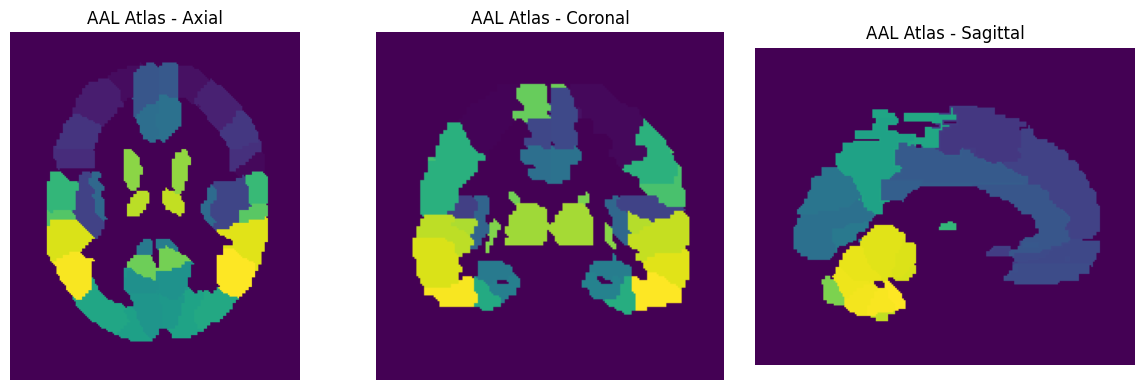

In [10]:
# Select middle slices from three anatomical planes
aal_axial = aal_data[:, :, aal_data.shape[2] // 2]
aal_coronal = aal_data[:, aal_data.shape[1] // 2, :]
aal_sagittal = aal_data[aal_data.shape[0] // 2, :, :]

# Display AAL atlas
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(aal_axial.T, origin="lower")
axes[0].set_title("AAL Atlas - Axial")
axes[0].axis("off")

axes[1].imshow(aal_coronal.T, origin="lower")
axes[1].set_title("AAL Atlas - Coronal")
axes[1].axis("off")

axes[2].imshow(aal_sagittal.T, origin="lower")
axes[2].set_title("AAL Atlas - Sagittal")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 9. Sex Information

In [ ]:
# Load sex information
sex_df = pd.read_csv(SEX_LIST_PATH)

print("Sex list shape:", sex_df.shape)

# Sample data with data types
sex_info = pd.DataFrame({
    "Column": sex_df.columns,
    "Data Type": sex_df.dtypes.astype(str).values,
    "Non-Null Values": sex_df.notna().sum().values,
    "Missing Values": sex_df.isna().sum().values})

display(sex_info)

# Sample records
display(sex_df.head())

# Sex distribution
display(sex_df.iloc[:, -1].value_counts(dropna=False).to_frame("Count"))

Sex list shape: (2511, 3)


,Column,Data Type,Non-Null Values,Missing Values
0,idx,int64,2511,0
1,Subject,str,2511,0
2,Sex,str,2511,0


,idx,Subject,Sex
0,0,941_S_6998,M
1,1,941_S_6962,F
2,2,941_S_6854,M
3,3,941_S_6803,F
4,4,941_S_6581,F


,Count
Sex,
M,1300
F,1210
X,1
